<a href="https://colab.research.google.com/github/SwRI-IDEA-Lab/butterflai/blob/development%2Fwilliam_keener/weeks/week_01/01_exploration.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Week 01: Sunspot Butterfly Diagram

This notebook reads the provided sunspot group catalog and plots the classic solar "butterfly diagram" (latitude vs time of emergence).

## 1) Setup (run this first)

This project is designed to run on Google Colab. Run the setup cell below to install dependencies and configure the environment.

In [2]:
# Standard ButterflAI Colab setup — always run this first
import os
import subprocess
import sys

repo_path = "/content/butterflai"
if not os.path.isdir(repo_path):
    subprocess.run(
        ["git", "clone", "https://github.com/SwRI-IDEA-Lab/butterflai.git", repo_path],
        check=True,
    )
else:
    subprocess.run(["git", "-C", repo_path, "pull"], check=True)

sys.path.insert(0, repo_path)
from infrastructure.utils.colab_setup import setup
setup()


  Installing from /content/butterflai/requirements.txt...

🦋 ButterflAI environment ready
   Runtime  : Google Colab
   Device   : cpu
   Seed     : 42


{'in_colab': True,
 'device': device(type='cpu'),
 'seed': 42,
 'drive_mounted': False,
 'data_path': None}

## 2) Load the Sunspot Group Catalog

We use the provided  file, which contains daily sunspot group measurements from 1825–2023.

In [3]:
import pandas as pd
from pathlib import Path

data_path = Path(repo_path) / 'data' / 'composite_sunspot_groups_daily_measurements_10_23.csv'
df = pd.read_csv(data_path, parse_dates=[[0, 1, 2]], keep_date_col=False)
df.rename(columns={"year_month_day": "date"}, inplace=True)

# Keep only rows with valid latitude (sunspot groups)
df = df[df["latitude"].notna()].copy()

# Quick sanity check
df[["date", "latitude", "CYCLE"]].head()


/tmp/ipykernel_27748/1667494998.py:5: FutureWarning: The 'keep_date_col' keyword in pd.read_csv is deprecated and will be removed in a future version. Explicitly remove unwanted columns after parsing instead.
  df = pd.read_csv(data_path, parse_dates=[[0, 1, 2]], keep_date_col=False)
/tmp/ipykernel_27748/1667494998.py:5: FutureWarning: Support for nested sequences for 'parse_dates' in pd.read_csv is deprecated. Combine the desired columns with pd.to_datetime after parsing instead.
  df = pd.read_csv(data_path, parse_dates=[[0, 1, 2]], keep_date_col=False)


,date,latitude,CYCLE
0,1825-11-05,-1.2,NaN
3,1825-11-08,-17.9,NaN
4,1825-11-09,-14.6,NaN
5,1825-11-10,-27.4,NaN
6,1825-11-11,-26.3,NaN


## 3) Plot the Butterfly Diagram

We plot emergence latitude vs. date. Points are colored by hemisphere (north vs south).

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


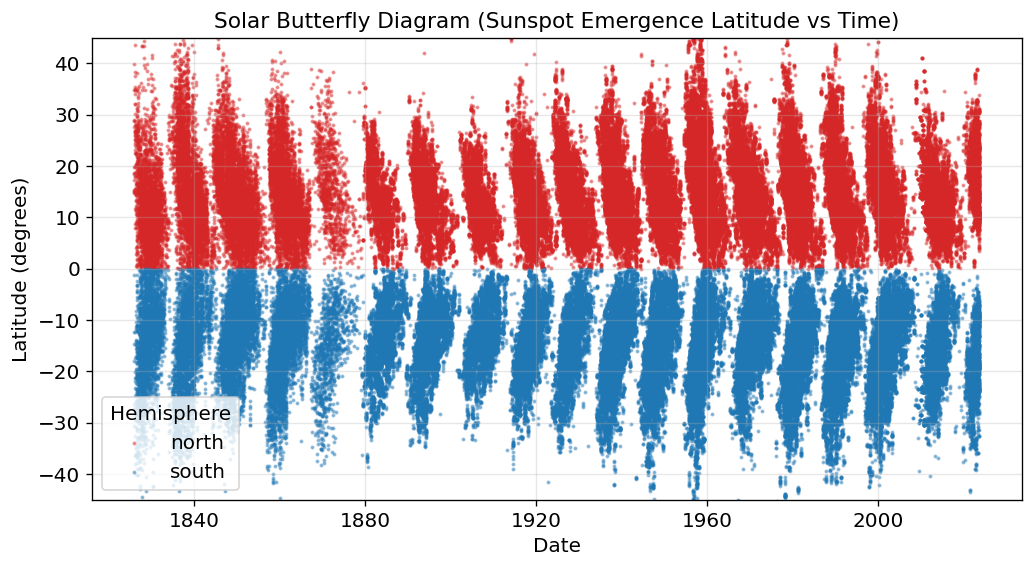

In [4]:
import matplotlib.pyplot as plt

df["hemisphere"] = df["latitude"].apply(lambda v: "north" if v >= 0 else "south")
colors = {"north": "tab:red", "south": "tab:blue"}

fig, ax = plt.subplots(figsize=(10, 5))
for hemi, group in df.groupby("hemisphere"):
    ax.scatter(group["date"], group["latitude"], s=2, c=colors[hemi], label=hemi, alpha=0.4)

ax.set_title("Solar Butterfly Diagram (Sunspot Emergence Latitude vs Time)")
ax.set_xlabel("Date")
ax.set_ylabel("Latitude (degrees)")
ax.legend(title="Hemisphere")
ax.set_ylim(-45, 45)
plt.show()


## 4) Exercise: Visualize Individual Solar Cycles

The butterfly diagram shows all cycles overlaid. Create a visualization that focuses on a single solar cycle (e.g., cycle 24, which is recent and well-observed).

**Task:**
- Filter the data to a specific cycle (use the  column).
- Plot the butterfly diagram for just that cycle.
- Experiment with different cycles and note any differences in shape or amplitude.

**Hint:** You can use the cycle column to filter.


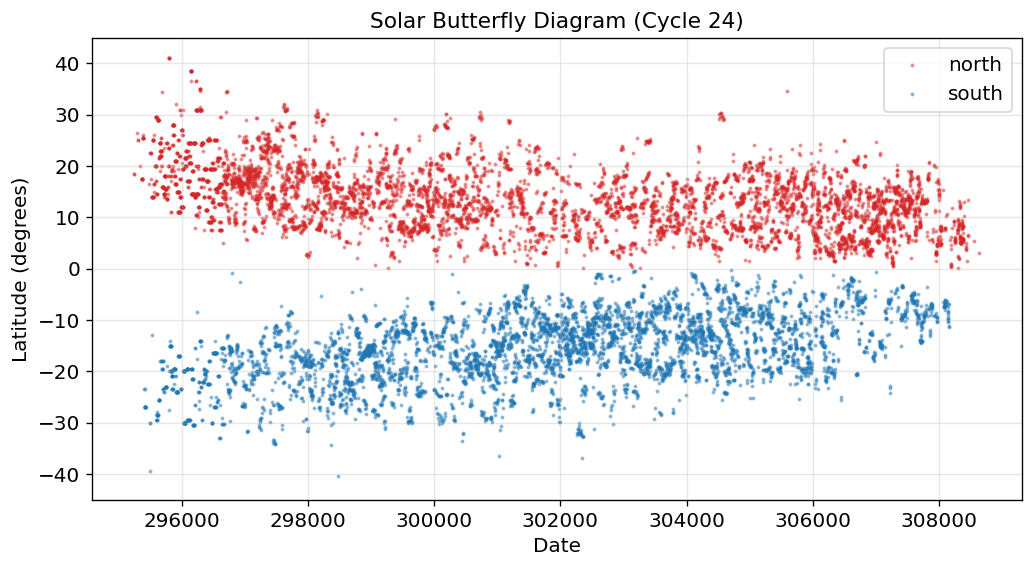

In [5]:
# Your code here: Visualize a single solar cycle
cycle_num = 24
df_cycle = df[df["CYCLE"] == cycle_num].copy()

fig, ax = plt.subplots(figsize=(10, 5))

for hemi, group in df_cycle.groupby("hemisphere"):
    ax.scatter(group.index, group["latitude"],
               s=2, alpha=0.4,
               c=colors[hemi], label=hemi)

ax.set_title(f"Solar Butterfly Diagram (Cycle {cycle_num})")
ax.set_xlabel("Date")
ax.set_ylabel("Latitude (degrees)")
ax.legend()
ax.set_ylim(-45, 45)

plt.show()

## 5) Exercise: Calculate Mean Latitudinal Paths

The "wings" of the butterfly diagram show the average latitude of sunspot emergence over time for each hemisphere.

**Task:**
- Group the data by hemisphere and calculate the mean latitude for each month/year.
- Plot the mean latitudinal path for the northern and southern hemispheres separately.
- Discuss: What does this tell us about the solar cycle's evolution?

**Hint:** Use  with  and date aggregation (e.g., resample by year).


/tmp/ipykernel_27748/1448103531.py:14: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  .resample("M")


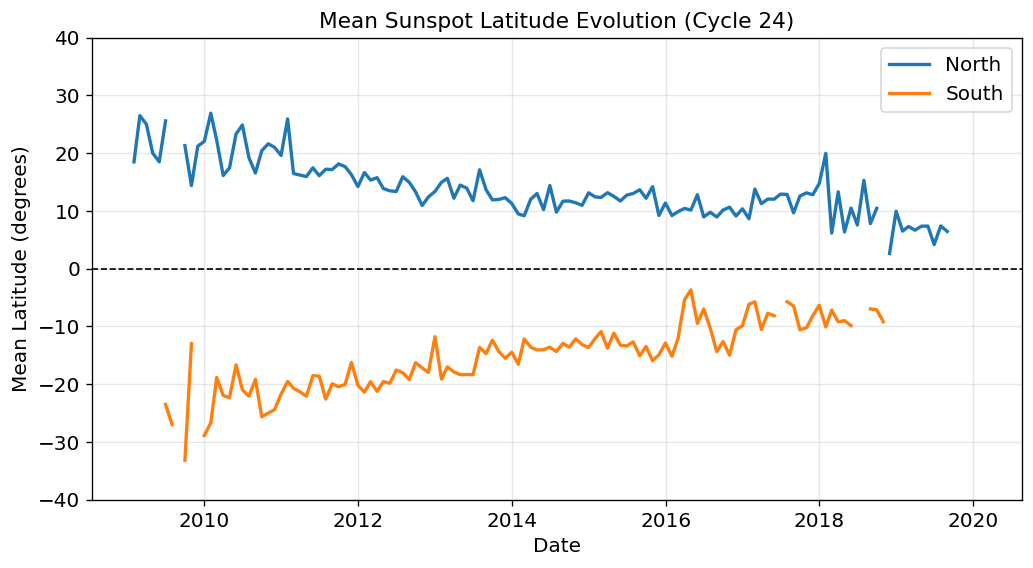

In [6]:
# Your code here: Calculate and plot mean latitudinal paths

# --- Filter to a single cycle ---
cycle_num = 24
df_cycle = df[df["CYCLE"] == cycle_num].copy()

# --- Set date as index for resampling ---
df_cycle = df_cycle.set_index("date")

# --- Group by hemisphere and resample monthly ---
mean_lat = (
    df_cycle
    .groupby("hemisphere")["latitude"]
    .resample("M")
    .mean()
    .reset_index()
)

# --- Plot ---
fig, ax = plt.subplots(figsize=(10, 5))

for hemi, group in mean_lat.groupby("hemisphere"):
    ax.plot(group["date"], group["latitude"],
            label=hemi.capitalize(),
            linewidth=2)

ax.axhline(0, color="k", linestyle="--", linewidth=1)
ax.set_title(f"Mean Sunspot Latitude Evolution (Cycle {cycle_num})")
ax.set_xlabel("Date")
ax.set_ylabel("Mean Latitude (degrees)")
ax.legend()
ax.set_ylim(-40, 40)

plt.show()

## 6) Reflection: Best Practices for AI-Assisted Learning

Throughout this program, you'll be working with AI assistants (like GitHub Copilot or Claude) to help with coding and understanding concepts.

**Task:**
- Ask your AI assistant: "What is the best way to prompt an AI assistant to help me learn machine learning and solar physics concepts effectively?"
- Write down their response and reflect: How will you apply this advice in future notebooks?

**Hint:** Be specific about what you want to learn and how you want the AI to explain it.


*Your reflection here:*


Below is the response from the AI. One thing that I have underutilitzed is the role fulfilling aspect of the AI. Using prompts that force you to do the work with guidance mimics the modern direct teaching methods employed in university. There is a lack in the response of "trust, but verify" the response.

Use the “Role + Level + Goal” Formula

Always anchor the assistant with who it is, your level, and what you want.

🔹 Example

“Act as a plasma physicist with ML experience. I’m an advanced undergrad with computational background. Teach me how to apply wavelet transforms to solar wind turbulence step-by-step.”

Why this works:

Prevents generic explanations
Tunes depth automatically
Keeps it aligned with your actual goals
2. Demand Structured Learning (Not Info Dumps)

Don’t ask:

“Explain neural networks”

Ask:

“Teach me neural networks in 5 steps:

intuition
math
implementation (Python)
pitfalls
application to solar wind data”

Now you get:

Concept → Math → Code → Application
instead of a philosophical essay about neurons having feelings
⚡ 3. Force Active Learning (This is the game-changer)

Make the AI challenge you, not just explain.

🔹 Example Prompts
“Give me a problem to solve before explaining the answer”
“Quiz me after each section”
“Make me derive the key equation instead of giving it directly”

This turns you from:

passive consumer → active researcher

🧮 4. Tie Everything to Your Domain (Solar Physics)

Never learn ML in isolation.

❌ Weak:

“Explain PCA”

✅ Strong:

“Explain PCA using solar wind turbulence data or PSP measurements as the example”

Even better:

“Show how PCA could separate compressive vs Alfvénic fluctuations”

Now it sticks—because it’s relevant to what you already think about.

🧰 5. Always Ask for Code + Interpretation

You want both:

implementation
physical meaning
🔹 Example

“Write Python code to compute a power spectrum from time series data, then explain what each step means physically for solar wind turbulence”

🧱 6. Build in Layers (Like a Skill Tree)

Use iterative prompts:

“Explain concept simply”
“Now show math”
“Now derive it”
“Now implement it”
“Now apply it to PSP data”
“Now show research-level caveats”

That’s how you go from:

“I’ve heard of this” → “I can publish with this”

🎯 7. Use the “Explain → Challenge → Extend” Loop
🔁 Cycle:
Explain concept
Give me a problem
Extend it to a harder case
🔹 Example

“Explain cross-helicity → give me a dataset-style problem → then extend it to imbalanced turbulence”

🧪 8. Ask for Mistakes and Failure Modes

This is huge for both ML and physics.

🔹 Example

“What are the most common mistakes when applying FFTs to solar wind data?”

“When does a neural network give physically meaningless results?”

That’s the difference between:

student knowledge
research-level intuition
🚀 9. Use “Compare & Contrast” Prompts
🔹 Example

“Compare wavelets vs FFT for detecting spectral breaks in solar wind turbulence”

“Compare random forests vs neural networks for classifying solar wind regimes”

This builds decision-making ability, not just knowledge.

🧠 10. Ask for Mental Models, Not Just Equations
🔹 Example

“Give me an intuitive picture of magnetic reconnection that I can visualize”

“Explain overfitting like a physical system analogy”

🧩 11. Use Project-Based Prompts (Best for You Specifically)

You’re already doing research—lean into that.

🔹 Example

“Help me design an ML pipeline to classify PSP turbulence intervals using sigma_c, beta, and spectral slopes”

Now the AI becomes:

co-author energy instead of textbook energy

🧠 Gold Standard Prompt Template (Use This)

When in doubt, use this:

Act as an expert in [field].

I am a [your level]. My goal is to [specific goal].

Teach me [topic] in this structure:
1) Intuition
2) Mathematical formulation
3) Step-by-step derivation (if applicable)
4) Python implementation
5) Application to [your domain: solar wind / PSP / turbulence]
6) Common pitfalls and limitations

Then:
- Give me a problem to solve
- Challenge me with a harder extension
⚠️ What NOT to Do
❌ “Explain X” (too vague)
❌ “Give me everything about Y” (you’ll get fluff)
❌ Learning ML without applying it immediately
❌ Letting the AI stay shallow (it will, if you let it)
🧠 Final Insight

The best prompt isn’t about wording—it’s about forcing the AI into a role where it has to think like a teacher, collaborator, and critic at the same time.

Or put differently:

If your prompt doesn’t make the AI slightly uncomfortable, it’s probably too easy